# Initial Setting
Several initialization steps are (exactly/roughly TODO: check) to those described in [tutorial_3DGS.ipynb](tutorial_3DGS.ipynb).

## Imports

In [1]:
import os
import torch
import numpy as np
import open3d as o3d
from random import randint
from utils.loss_utils import l1_loss, ssim
from gaussian_renderer import render, network_gui
import sys
from scene import Scene, GaussianModel
from utils.general_utils import safe_state, get_expon_lr_func
import uuid
from tqdm import tqdm
from utils.image_utils import psnr
from argparse import ArgumentParser, Namespace
from arguments import ModelParams, PipelineParams, OptimizationParams
from scene.dataset_readers import sceneLoadTypeCallbacks
try:
    from torch.utils.tensorboard import SummaryWriter
    TENSORBOARD_FOUND = True
except ImportError:
    TENSORBOARD_FOUND = False

try:
    from fused_ssim import fused_ssim
    FUSED_SSIM_AVAILABLE = True
except:
    FUSED_SSIM_AVAILABLE = False

try:
    from diff_gaussian_rasterization import SparseGaussianAdam
    SPARSE_ADAM_AVAILABLE = True
except:
    SPARSE_ADAM_AVAILABLE = False

def prepare_output_and_logger(args):    
    if not args.model_path:
        if os.getenv('OAR_JOB_ID'):
            unique_str=os.getenv('OAR_JOB_ID')
        else:
            unique_str = str(uuid.uuid4())
        args.model_path = os.path.join("./output/", unique_str[0:10])
        
    # Set up output folder
    print("Output folder: {}".format(args.model_path))
    os.makedirs(args.model_path, exist_ok = True)
    with open(os.path.join(args.model_path, "cfg_args"), 'w') as cfg_log_f:
        cfg_log_f.write(str(Namespace(**vars(args))))

    # Create Tensorboard writer
    tb_writer = None
    if TENSORBOARD_FOUND:
        tb_writer = SummaryWriter(args.model_path)
    else:
        print("Tensorboard not available: not logging progress")
    return tb_writer



def training_report(tb_writer, iteration, Ll1, loss, l1_loss, elapsed, testing_iterations, scene : Scene, renderFunc, renderArgs, train_test_exp):
    if tb_writer:
        tb_writer.add_scalar('train_loss_patches/l1_loss', Ll1.item(), iteration)
        tb_writer.add_scalar('train_loss_patches/total_loss', loss.item(), iteration)
        tb_writer.add_scalar('iter_time', elapsed, iteration)

    # Report test and samples of training set
    if iteration in testing_iterations:
        torch.cuda.empty_cache()
        validation_configs = ({'name': 'test', 'cameras' : scene.getTestCameras()}, 
                              {'name': 'train', 'cameras' : [scene.getTrainCameras()[idx % len(scene.getTrainCameras())] for idx in range(5, 30, 5)]})

        for config in validation_configs:
            if config['cameras'] and len(config['cameras']) > 0:
                l1_test = 0.0
                psnr_test = 0.0
                for idx, viewpoint in enumerate(config['cameras']):
                    image = torch.clamp(renderFunc(viewpoint, scene.gaussians, *renderArgs)["render"], 0.0, 1.0)
                    gt_image = torch.clamp(viewpoint.original_image.to("cuda"), 0.0, 1.0)
                    if train_test_exp:
                        image = image[..., image.shape[-1] // 2:]
                        gt_image = gt_image[..., gt_image.shape[-1] // 2:]
                    if tb_writer and (idx < 5):
                        tb_writer.add_images(config['name'] + "_view_{}/render".format(viewpoint.image_name), image[None], global_step=iteration)
                        if iteration == testing_iterations[0]:
                            tb_writer.add_images(config['name'] + "_view_{}/ground_truth".format(viewpoint.image_name), gt_image[None], global_step=iteration)
                    l1_test += l1_loss(image, gt_image).mean().double()
                    psnr_test += psnr(image, gt_image).mean().double()
                psnr_test /= len(config['cameras'])
                l1_test /= len(config['cameras'])          
                print("\n[ITER {}] Evaluating {}: L1 {} PSNR {}".format(iteration, config['name'], l1_test, psnr_test))
                if tb_writer:
                    tb_writer.add_scalar(config['name'] + '/loss_viewpoint - l1_loss', l1_test, iteration)
                    tb_writer.add_scalar(config['name'] + '/loss_viewpoint - psnr', psnr_test, iteration)

        if tb_writer:
            tb_writer.add_histogram("scene/opacity_histogram", scene.gaussians.get_opacity, iteration)
            tb_writer.add_scalar('total_points', scene.gaussians.get_xyz.shape[0], iteration)
        torch.cuda.empty_cache()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Parser Setting

In [2]:
parser = ArgumentParser(description="Training script parameters")
lp = ModelParams(parser)
op = OptimizationParams(parser)
pp = PipelineParams(parser)
parser.add_argument('--ip', type=str, default="127.0.0.1")
parser.add_argument('--port', type=int, default=6009)
parser.add_argument('--debug_from', type=int, default=-1)
parser.add_argument('--detect_anomaly', action='store_true', default=False)
parser.add_argument("--test_iterations", nargs="+", type=int, default=[7_000, 30_000])
parser.add_argument("--save_iterations", nargs="+", type=int, default=[7_000, 30_000])
parser.add_argument("--quiet", action="store_true")
parser.add_argument('--disable_viewer', action='store_true', default=False)
parser.add_argument("--checkpoint_iterations", nargs="+", type=int, default=[])
parser.add_argument("--start_checkpoint", type=str, default=None)

# In Jupyter, parse_known_args avoids runtime arguments such as -f that are injected by the notebook kernel.
args, _ = parser.parse_known_args([])
args.save_iterations.append(args.iterations)

# Convert the parser namespace into the lightweight argument objects used by the training code.
model_args = lp.extract(args)
opt_args = op.extract(args)
pipe_args = pp.extract(args)
model_args.source_path = os.path.join(model_args.source_path,"GaussianTest/Test2") 
# source_path is hardcoded on purpose for this tutorial, but you can change it to your own dataset path.

print("Loaded parser-backed arguments")
print("sh_degree:", model_args.sh_degree)
print("optimizer_type:", opt_args.optimizer_type)
print("source path: ", model_args.source_path)

Loaded parser-backed arguments
sh_degree: 3
optimizer_type: default
source path:  c:\Users\chang\gaussian-splatting\GaussianTest/Test2


## Setup Before Training

In [3]:
first_iter = 0
tb_writer = prepare_output_and_logger(model_args)
gaussians = GaussianModel(model_args.sh_degree, opt_args.optimizer_type)
scene1 = Scene(model_args, gaussians)
gaussians.training_setup(opt_args)
if args.checkpoint_iterations:
    (model_params, first_iter) = torch.load(args.checkpoint)
    gaussians.restore(model_params, opt_args)

bg_color = [1, 1, 1] if model_args.white_background else [0, 0, 0]
background = torch.tensor(bg_color, dtype=torch.float32, device="cuda")

iter_start = torch.cuda.Event(enable_timing = True)
iter_end = torch.cuda.Event(enable_timing = True)

use_sparse_adam = opt_args.optimizer_type == "sparse_adam" and SPARSE_ADAM_AVAILABLE 
depth_l1_weight = get_expon_lr_func(opt_args.depth_l1_weight_init, opt_args.depth_l1_weight_final, max_steps=opt_args.iterations)

viewpoint_stack = scene1.getTrainCameras().copy()
viewpoint_indices = list(range(len(viewpoint_stack)))
ema_loss_for_log = 0.0
ema_Ll1depth_for_log = 0.0

progress_bar = tqdm(range(first_iter, opt_args.iterations), desc="Training progress")
first_iter += 1

Output folder: ./output/15bc123c-8
Tensorboard not available: not logging progress
Reading camera 25/25
Loading Training Cameras
Loading Test Cameras
Number of points at initialisation :  1768


Training progress:   0%|          | 0/30000 [00:00<?, ?it/s]

# Start Training

Code from (TODO: link file/line)

TODO: print부분은 [`GaussianModel.densify_and_clone()` method](./scene/gaussian_model.py#439), (TODO: print 있는 다른 메소드도 언급 추가)에 있음

Among the for loop code below, clone, split, and pruning are performed in: Lines 88-90 (TODO:Check)
```python
    if iteration > opt_args.densify_from_iter and iteration % opt_args.densification_interval == 0:
        size_threshold = 20 if iteration > opt_args.opacity_reset_interval else None
        gaussians.densify_and_prune(opt_args.densify_grad_threshold, 0.005, scene1.cameras_extent, size_threshold, radii)
```


Call stack:
* Main training loop iteration
  * [`GaussianModel.densify_and_prune()`](TODO_LINK)
    * [`GaussianModel.densify_and_clone()`](TODO_LINK): performs cloning
    * [`GaussianModel.densify_and_split()`](TODO_LINK) : performs splitting and pruning

In [ ]:
for iteration in range(first_iter, 1000):
    iter_start.record()
    
    gaussians.update_learning_rate(iteration)
    
    # Every 1000 its we increase the levels of SH up to a maximum degree
    if iteration % 1000 == 0:
        gaussians.oneupSHdegree()
    
    # Pick a random Camera
    if not viewpoint_stack:
        viewpoint_stack = scene1.getTrainCameras().copy()
        viewpoint_indices = list(range(len(viewpoint_stack)))
    rand_idx = randint(0, len(viewpoint_indices) - 1)
    viewpoint_cam = viewpoint_stack.pop(rand_idx)
    vind = viewpoint_indices.pop(rand_idx)
    
    # Render
    if (iteration - 1) == args.debug_from:
        pipe_args.debug = True
    
    bg = torch.rand((3), device="cuda") if opt_args.random_background else background
    
    render_pkg = render(viewpoint_cam, gaussians, pipe_args, bg, use_trained_exp=model_args.train_test_exp, separate_sh=SPARSE_ADAM_AVAILABLE)
    image, viewspace_point_tensor, visibility_filter, radii = render_pkg["render"], render_pkg["viewspace_points"], render_pkg["visibility_filter"], render_pkg["radii"]
    
    if viewpoint_cam.alpha_mask is not None:
        alpha_mask = viewpoint_cam.alpha_mask.cuda()
        image *= alpha_mask
    
    # Loss
    gt_image = viewpoint_cam.original_image.cuda()
    Ll1 = l1_loss(image, gt_image)
    if FUSED_SSIM_AVAILABLE:
        ssim_value = fused_ssim(image.unsqueeze(0), gt_image.unsqueeze(0))
    else:
        ssim_value = ssim(image, gt_image)
    
    loss = (1.0 - opt_args.lambda_dssim) * Ll1 + opt_args.lambda_dssim * (1.0 - ssim_value)
    
    # Depth regularization
    Ll1depth_pure = 0.0
    if depth_l1_weight(iteration) > 0 and viewpoint_cam.depth_reliable:
        invDepth = render_pkg["depth"]
        mono_invdepth = viewpoint_cam.invdepthmap.cuda()
        depth_mask = viewpoint_cam.depth_mask.cuda()
    
        Ll1depth_pure = torch.abs((invDepth  - mono_invdepth) * depth_mask).mean()
        Ll1depth = depth_l1_weight(iteration) * Ll1depth_pure 
        loss += Ll1depth
        Ll1depth = Ll1depth.item()
    else:
        Ll1depth = 0
    
    loss.backward()
    
    iter_end.record()
    
    with torch.no_grad():
        # Progress bar
        ema_loss_for_log = 0.4 * loss.item() + 0.6 * ema_loss_for_log
        ema_Ll1depth_for_log = 0.4 * Ll1depth + 0.6 * ema_Ll1depth_for_log
    
        if iteration % 10 == 0:
            progress_bar.set_postfix({"Loss": f"{ema_loss_for_log:.{7}f}", "Depth Loss": f"{ema_Ll1depth_for_log:.{7}f}"})
            progress_bar.update(10)
        if iteration == opt_args.iterations:
            progress_bar.close()
    
        # Log and save
        training_report(tb_writer, iteration, Ll1, loss, l1_loss, iter_start.elapsed_time(iter_end), args.test_iterations, scene1, render, (pipe_args, background, 1., SPARSE_ADAM_AVAILABLE, None, model_args.train_test_exp), model_args.train_test_exp)
        if (iteration in args.save_iterations):
            print("\n[ITER {}] Saving Gaussians".format(iteration))
            scene1.save(iteration)
    
        # Densification
        if iteration < opt_args.densify_until_iter:
            # Keep track of max radii in image-space for pruning
            gaussians.max_radii2D[visibility_filter] = torch.max(gaussians.max_radii2D[visibility_filter], radii[visibility_filter])
            gaussians.add_densification_stats(viewspace_point_tensor, visibility_filter)
            check_grads = gaussians.xyz_gradient_accum # not inside train.py
            check_xyzs = gaussians.get_xyz # not inside train.py
            check_scaling = gaussians.get_scaling # not inside train.py
            check_opacity= gaussians.get_opacity # not inside train.py
            check_rotation= gaussians._rotation # not inside train.py
            check_denom = gaussians.denom # not inside train.py
    
            if iteration > opt_args.densify_from_iter and iteration % opt_args.densification_interval == 0:
                size_threshold = 20 if iteration > opt_args.opacity_reset_interval else None
                gaussians.densify_and_prune(opt_args.densify_grad_threshold, 0.005, scene1.cameras_extent, size_threshold, radii)
                
    
            if iteration % opt_args.opacity_reset_interval == 0 or (model_args.white_background and iteration == opt_args.densify_from_iter):
                gaussians.reset_opacity()

        # Optimizer step
        if iteration < opt_args.iterations:
            gaussians.exposure_optimizer.step()
            gaussians.exposure_optimizer.zero_grad(set_to_none = True)
            if use_sparse_adam:
                visible = radii > 0
                gaussians.optimizer.step(visible, radii.shape[0])
                gaussians.optimizer.zero_grad(set_to_none = True)
            else:
                gaussians.optimizer.step()
                gaussians.optimizer.zero_grad(set_to_none = True)
        
        if (iteration in args.checkpoint_iterations):
            print("\n[ITER {}] Saving Checkpoint".format(iteration))
            torch.save((gaussians.capture(), iteration), scene1.model_path + "/chkpnt" + str(iteration) + ".pth")

Training progress:   2%|▏         | 600/30000 [00:44<36:01, 13.60it/s, Loss=0.1002721, Depth Loss=0.0000000]

--- 증식 전 총 가우시안: 1768 ---
 복제(Clone)된 가우시안 개수: 9
Clone 직후 총 가우시안: 1777
 분할(Split)된 원본 가우시안 개수: 529 (이것이 2배로 쪼개짐)
Split 직후 총 가우시안: 2306
Prune 직후 최종 가우시안: 2306


Training progress:   2%|▏         | 700/30000 [00:51<37:04, 13.17it/s, Loss=0.0809387, Depth Loss=0.0000000]

--- 증식 전 총 가우시안: 2306 ---
 복제(Clone)된 가우시안 개수: 40
Clone 직후 총 가우시안: 2346
 분할(Split)된 원본 가우시안 개수: 931 (이것이 2배로 쪼개짐)
Split 직후 총 가우시안: 3277
Prune 직후 최종 가우시안: 3276


Training progress:   3%|▎         | 800/30000 [00:59<37:59, 12.81it/s, Loss=0.0763521, Depth Loss=0.0000000]

--- 증식 전 총 가우시안: 3276 ---
 복제(Clone)된 가우시안 개수: 125
Clone 직후 총 가우시안: 3401
 분할(Split)된 원본 가우시안 개수: 1526 (이것이 2배로 쪼개짐)
Split 직후 총 가우시안: 4927
Prune 직후 최종 가우시안: 4927


Training progress:   3%|▎         | 900/30000 [01:07<37:44, 12.85it/s, Loss=0.0556212, Depth Loss=0.0000000]

--- 증식 전 총 가우시안: 4927 ---
 복제(Clone)된 가우시안 개수: 292
Clone 직후 총 가우시안: 5219
 분할(Split)된 원본 가우시안 개수: 2261 (이것이 2배로 쪼개짐)
Split 직후 총 가우시안: 7480
Prune 직후 최종 가우시안: 7479


Training progress:   3%|▎         | 990/30000 [01:14<37:53, 12.76it/s, Loss=0.0723951, Depth Loss=0.0000000]

# Copying and Pruning

The cell below shows the ellipsoid of where the first gaussian is set.  

check_grads, check_xyzs, check_scaling, check_opacity, check_rotation, check_denom are datas before last iteration.

And now I'm going to check which gaussians will be copied or splitted

Let's find gaussians that are going to be copied

In [5]:
real_grad = check_grads/check_denom
real_grad[real_grad.isnan()] = 0.0
find_grads=torch.norm(real_grad,dim=-1)

## densify_and_clone
[densify_and_clone](scene/gaussian_model.py#439)
```python
def densify_and_clone(self, grads, grad_threshold, scene_extent):
    # Extract points that satisfy the gradient condition
    selected_pts_mask = torch.where(torch.norm(grads, dim=-1) >= grad_threshold, True, False)
    selected_pts_mask = torch.logical_and(selected_pts_mask,
                                                torch.max(self.get_scaling, dim=1).values <= self.percent_dense*scene_extent)
    ...
```

In [6]:
cond1 = find_grads>opt_args.densify_grad_threshold
cond2 = torch.max(check_scaling, dim=1).values <= gaussians.percent_dense*scene1.cameras_extent
combined_cond = cond1&cond2
selected_indices = combined_cond.nonzero(as_tuple = True)[0]
print(len(selected_indices))
print(selected_indices)
index=selected_indices[0]

577
tensor([ 101,  113,  221,  434,  481,  485,  488,  570,  758,  832,  839,  901,
         918,  919,  921,  922,  923,  965,  968,  969,  984, 1020, 1041, 1056,
        1058, 1059, 1061, 1103, 1104, 1109, 1116, 1119, 1121, 1127, 1128, 1129,
        1131, 1135, 1137, 1138, 1157, 1167, 1168, 1169, 1170, 1172, 1181, 1183,
        1185, 1199, 1201, 1214, 1217, 1248, 1249, 1250, 1253, 1264, 1344, 1346,
        1349, 1350, 1351, 1352, 1365, 1368, 1369, 1378, 1400, 1406, 1408, 1411,
        1415, 1420, 1440, 1452, 1454, 1455, 1459, 1481, 1484, 1499, 1502, 1524,
        1531, 1535, 1536, 1540, 1547, 1549, 1551, 1554, 1558, 1567, 1569, 1583,
        1588, 1592, 1594, 1595, 1597, 1599, 1605, 1606, 1608, 1614, 1618, 1621,
        1622, 1625, 1628, 1629, 1633, 1637, 1640, 1658, 1671, 1717, 1722, 1724,
        1727, 1741, 1745, 1750, 1775, 1776, 1782, 1786, 1795, 1809, 1828, 1833,
        1838, 1841, 1842, 1843, 1848, 1854, 1860, 1884, 1938, 1944, 1947, 1948,
        1951, 1953, 1963, 1964, 1967

In [7]:
print(opt_args.densify_grad_threshold)

0.0002


In [8]:
print(f"grad bigger than threshold: {cond1[index]}")

grad bigger than threshold: True


In [9]:
print(f"Scale smaller than threshold: {cond2[index]}")

Scale smaller than threshold: True


RFBOutputContext()

CanvasBackend(css_height='600px', css_width='800px')
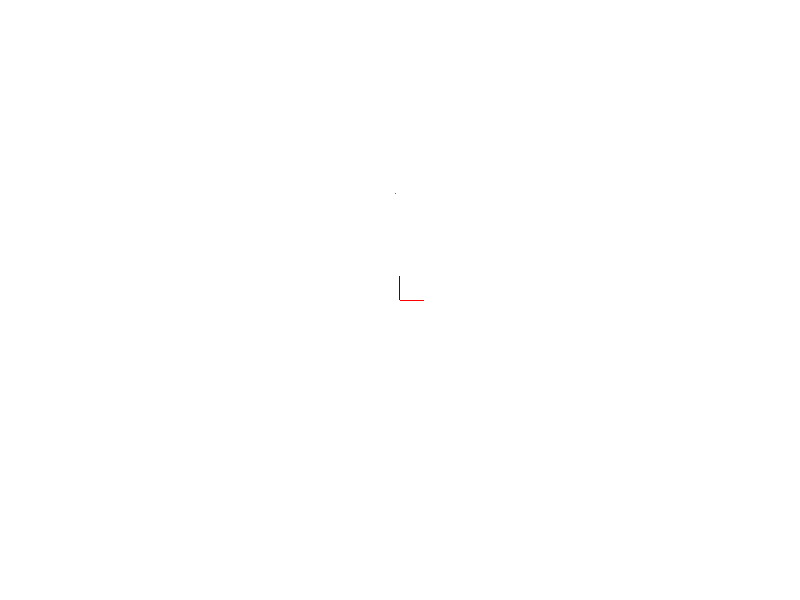

In [10]:
# Visualize Gaussian ellipsoids in 3D with Vispy
import numpy as np
from vispy import scene, app
from vispy.visuals.transforms import MatrixTransform
from utils.general_utils import build_rotation

# app.use_app('jupyter_rfb')

points = check_xyzs[index].detach().cpu().numpy()
scales = check_scaling[index].detach().cpu().numpy()
opacities = check_opacity[index].detach().cpu().numpy().squeeze()
rotations = build_rotation(check_rotation)[index].detach().cpu().numpy()


from vispy.geometry import create_sphere
sphere = create_sphere(rows=24, cols=24, radius=1.0)
vertices = sphere.get_vertices()
faces = sphere.get_faces()


canvas = scene.SceneCanvas(keys='interactive', show=True, bgcolor='white', title='Gaussian Ellipsoids')
view = canvas.central_widget.add_view()
view.camera = 'arcball'
view.camera.fov = 45
view.camera.distance = 30

#for p, s, o, R in zip(points, scales, opacities, rotations):
transform = MatrixTransform()
matrix = np.eye(4, dtype=np.float32)
matrix[:3, :3] = rotations @ np.diag(scales.astype(np.float32))
matrix[:3, 3] = points.astype(np.float32)
transform.matrix = matrix.T

color = (0.2, 0.6, 1.0, float(np.clip(opacities, 0.05, 1.0)))
mesh = scene.visuals.Mesh(vertices=vertices, faces=faces, color=color, shading='smooth', parent=view.scene)
mesh.transform = transform

axis = scene.visuals.XYZAxis(parent=view.scene)
canvas

This gaussian is going to be cloned.(it's so small so it is shown like a dot)

## densify_and_split

```python
def densify_and_split(self, grads, grad_threshold, scene_extent, N=2):
    n_init_points = self.get_xyz.shape[0]
    # Extract points that satisfy the gradient condition
    padded_grad = torch.zeros((n_init_points), device="cuda")
    padded_grad[:grads.shape[0]] = grads.squeeze()
    selected_pts_mask = torch.where(padded_grad >= grad_threshold, True, False)
    selected_pts_mask = torch.logical_and(selected_pts_mask,
                                              torch.max(self.get_scaling, dim=1).values > self.percent_dense*scene_extent)
    ...
```

In [11]:
cond3 = torch.max(check_scaling, dim=1).values > gaussians.percent_dense*scene1.cameras_extent
combined_cond2 = cond1&cond3
selected_indices2 = combined_cond2.nonzero(as_tuple = True)[0]
print(len(selected_indices2))
print(selected_indices2)

3253
tensor([  21,   33,   35,  ..., 7473, 7474, 7477], device='cuda:0')


In [12]:
print(f"grad bigger than threshold: {cond1[index]}")
print(f"Scale smaller than threshold: {cond3[index]}")

grad bigger than threshold: True
Scale smaller than threshold: False


RFBOutputContext()

CanvasBackend(css_height='600px', css_width='800px')
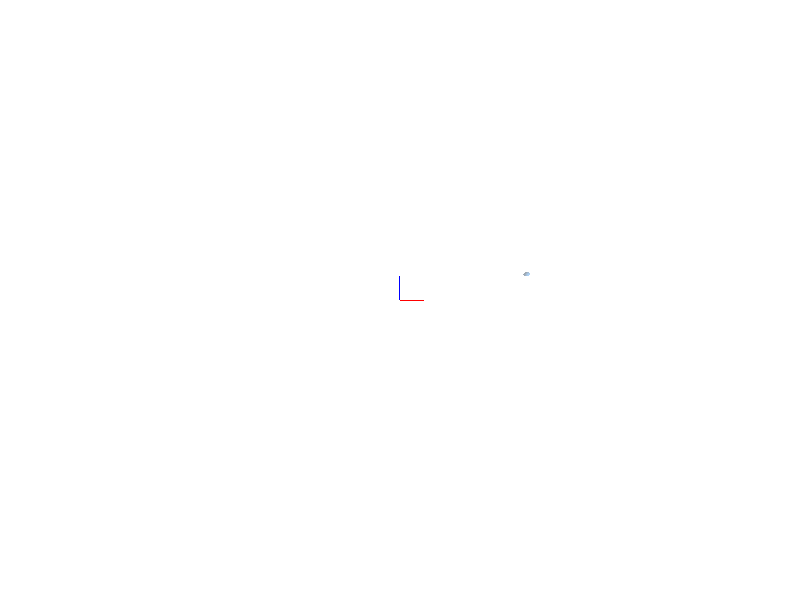

In [13]:
index=selected_indices2[0]

points = check_xyzs[index].detach().cpu().numpy()
scales = check_scaling[index].detach().cpu().numpy()
opacities = check_opacity[index].detach().cpu().numpy().squeeze()
rotations = build_rotation(check_rotation)[index].detach().cpu().numpy()


from vispy.geometry import create_sphere
sphere = create_sphere(rows=24, cols=24, radius=1.0)
vertices = sphere.get_vertices()
faces = sphere.get_faces()


canvas = scene.SceneCanvas(keys='interactive', show=True, bgcolor='white', title='Gaussian Ellipsoids')
view = canvas.central_widget.add_view()
view.camera = 'arcball'
view.camera.fov = 45
view.camera.distance = 30

#for p, s, o, R in zip(points, scales, opacities, rotations):
transform = MatrixTransform()
matrix = np.eye(4, dtype=np.float32)
matrix[:3, :3] = rotations @ np.diag(scales.astype(np.float32))
matrix[:3, 3] = points.astype(np.float32)
transform.matrix = matrix.T

color = (0.2, 0.6, 1.0, float(np.clip(opacities, 0.05, 1.0)))
mesh = scene.visuals.Mesh(vertices=vertices, faces=faces, color=color, shading='smooth', parent=view.scene)
mesh.transform = transform

axis = scene.visuals.XYZAxis(parent=view.scene)
canvas

This gaussian will be splitted.

In [14]:
gaussians.densify_and_prune(opt_args.densify_grad_threshold, 0.005, scene1.cameras_extent, size_threshold, radii)

--- 증식 전 총 가우시안: 7479 ---
 복제(Clone)된 가우시안 개수: 576
Clone 직후 총 가우시안: 8055
 분할(Split)된 원본 가우시안 개수: 3254 (이것이 2배로 쪼개짐)
Split 직후 총 가우시안: 11309
Prune 직후 최종 가우시안: 11308


Training progress:   3%|▎         | 990/30000 [01:30<37:53, 12.76it/s, Loss=0.0723951, Depth Loss=0.0000000]